# Buổi 12 — Khử nhiễu và miền tần số

**Một câu:** bộ lọc nào cũng đổi độ trơn lấy **trễ** hoặc lấy việc **nhìn tương lai**; loại nhìn tương lai cho kết quả chấm đẹp giả, nên
trước khi dùng một bộ lọc làm feature phải kiểm nó bằng máy.

Tình huống: điện thiết bị của một ngôi nhà ở Bỉ, 10 phút một mẫu, nhảy lên xuống theo từng lần bật ấm, bật máy giặt. Muốn dự báo một giờ
tới, ai cũng muốn "làm trơn cho bớt nhiễu": làm bằng gì, mất gì, và làm sao biết mình không vô tình dùng tương lai?

| Phần | Câu hỏi |
|---|---|
| 1 | Trung bình trượt kiểu nào nhìn tương lai? |
| 2 | Chuỗi có nhiễu để lọc không — phổ nói gì? |
| 3 | Vì sao hạ mẫu có thể sinh ra một chu kỳ không có thật? |
| 4 | Sáu họ bộ lọc: cái nào trơn, cái nào trễ, cái nào dùng tương lai? |
| 5 | Kiểm "có nhìn tương lai không" bằng máy thế nào? |
| 6 | Rò rỉ làm sai số đẹp giả bao nhiêu? |

## 0. Dữ liệu

**Bộ dữ liệu Appliances Energy Prediction.** Điện năng thiết bị của **một ngôi nhà** ở Stambruges (Bỉ) đo **mỗi 10 phút** trong khoảng 4,5 tháng (11/1 → 27/5/2016),
kèm nhiệt độ, độ ẩm từ cảm biến không dây trong từng phòng và thời tiết của trạm sân bay gần đó. Một tệp CSV 19.735 dòng,
mỗi dòng là **10 phút**.

Nguồn: Candanedo, L. (2017). Appliances Energy Prediction [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5VC8G. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `date` | thời điểm đo (giờ địa phương) |
| `Appliances` | điện năng thiết bị trong 10 phút, Wh — chuỗi của buổi |
| `lights` | điện năng đèn, Wh |
| `T1…T9`, `RH_1…RH_9` | nhiệt độ (°C) và độ ẩm (%) của từng phòng |
| `T_out`, `RH_out`, `Windspeed…` | thời tiết ngoài trời từ trạm sân bay Chièvres |
| `rv1`, `rv2` | hai cột số ngẫu nhiên nhóm tác giả thêm vào để thử cách chọn biến |

Ô dưới tải dữ liệu (12 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "uci-appliances-energy": ("2fccf354445d886e7917620b0195db1f3e3e34d5a067a93b844694a4c561255a", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-appliances-energy/appliances+energy+prediction.zip",
        "https://archive.ics.uci.edu/static/public/374/appliances+energy+prediction.zip",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from scipy import signal
from statsmodels.tsa.statespace.structural import UnobservedComponents

FS = 6.0   # số mẫu mỗi giờ (10 phút một mẫu)
TAM = 6    # dự báo 1 giờ tới = 6 bước

with zipfile.ZipFile(lay("uci-appliances-energy")) as z, z.open("energydata_complete.csv") as f:
    df = pd.read_csv(f, parse_dates=["date"]).set_index("date").asfreq("10min")
df = df[["Appliances", "T2"]].astype(float)
print(f"{len(df):,} mẫu, {df.index[0]} → {df.index[-1]}, ô thiếu: {int(df.isna().sum().sum())}")
print(df.describe().loc[["mean", "std", "min", "max"]].round(1))

## 1. Trung bình trượt có tâm sửa cả quá khứ khi dữ liệu mới về

**Vấn đề.** Đường làm trơn đẹp nhất thường đến từ bộ lọc dùng cả số **sau** thời điểm đang tính. Mô tả lịch sử thì không sao; làm feature
dự báo thì backtest (chấm trên quá khứ) đẹp, dùng thật thì sập.

> **feature / mục tiêu** · *feature / target*
>
> - **Là gì:** feature là cột đầu vào mô hình dùng để dự báo; mục tiêu là con số cần dự báo, cũng là con số dùng để chấm.
> - **Ví dụ:** dự báo điện giờ tới (mục tiêu) từ điện hiện tại và điện trung bình 2 giờ qua (hai feature).
> - **Để làm gì:** bộ lọc chen vào được hai chỗ: làm trơn feature (được, nếu nhân quả) và làm trơn mục tiêu (không được).

> **tín hiệu / nhiễu** · *signal / noise*
>
> - **Là gì:** chuỗi = tín hiệu (phần có quy luật, muốn giữ) + nhiễu (phần ngẫu nhiên, không dự báo được).
> - **Ví dụ:** nhịp ngày của điện (sáng tối dùng nhiều) là tín hiệu; một lần bật ấm đun 5 phút là nhiễu.
> - **Để làm gì:** khử nhiễu là ước lượng phần tín hiệu.

> **bộ lọc (filter)** · *filter*
>
> - **Là gì:** phép biến một chuỗi thành chuỗi khác, thường để làm trơn.
> - **Ví dụ:** trung bình trượt 3 điểm biến 10, 12, 14 thành 12.
> - **Để làm gì:** làm trơn feature, tách xu hướng, vẽ báo cáo.

> **bộ lọc nhân quả** · *causal filter*
>
> - **Là gì:** bộ lọc mà đầu ra tại $t$ chỉ dùng dữ liệu tới $t$, không dùng $y_{t+1}, y_{t+2}, \dots$
> - **Ví dụ:** trung bình 3 điểm **gần nhất** (trailing) là nhân quả; trung bình giờ trước, giờ này, giờ sau (centered) thì không.
> - **Để làm gì:** chỉ bộ lọc nhân quả được dùng làm feature dự báo — lúc dự báo thật không có số của tương lai.
>
> 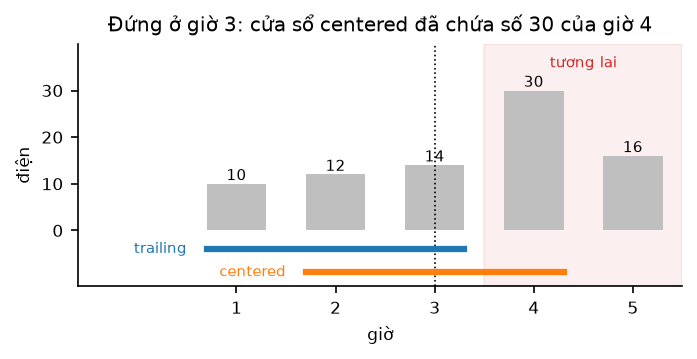

> **trễ (pha)** · *phase lag*
>
> - **Là gì:** đầu ra bộ lọc chạy sau tín hiệu thật bao nhiêu bước.
> - **Ví dụ:** trung bình 13 điểm gần nhất trễ $(13 - 1)/2$ = 6 bước: đỉnh thật lúc $t$ thì đỉnh đầu ra lúc $t + 6$.
> - **Để làm gì:** trễ là cái giá của bộ lọc nhân quả; trễ gần bằng tầm dự báo thì feature vô dụng.
>
> 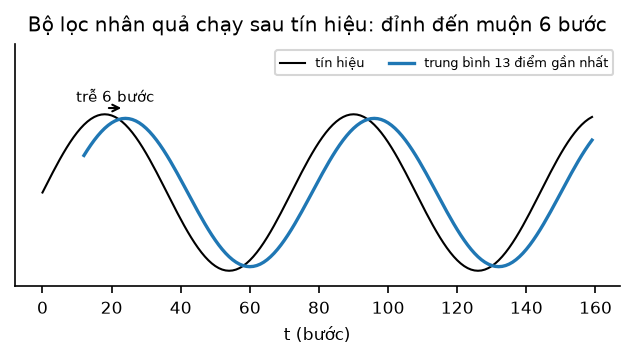

**Lý do.** Kiểu centered có nửa cửa sổ nằm ở tương lai, nên khi một số mới về, giá trị đã tính cho quá khứ đổi theo. Kiểu trailing
không bao giờ như thế — đổi lại nó trễ.

**Kết quả.** Năm giờ điện 10, 12, 14, 30, 16; rồi đổi giờ cuối thành 40:

In [ ]:
y = pd.Series([10, 12, 14, 30, 16], index=range(1, 6), dtype=float)
print(pd.DataFrame({"điện": y, "trailing": y.rolling(3).mean(), "centered": y.rolling(3, center=True).mean()}).round(2).T)
y2 = y.copy()
y2[5] = 40
print(f"giờ 4 sau khi giờ 5 đổi 16 → 40: trailing {y2.rolling(3).mean()[4]:.2f} | centered {y2.rolling(3, center=True).mean()[4]:.2f}")

ngay = df.loc["2016-05-02", "Appliances"]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(ngay, color="0.7", lw=0.8, label="điện (Wh / 10 phút)")
ax.plot(ngay.rolling(13).mean(), lw=1.6, label="trailing 13 (≈ 2 giờ)")
ax.plot(ngay.rolling(13, center=True).mean(), lw=1.6, label="centered 13")
ax.set(title="Một ngày: trailing lên sau đỉnh, centered lên đúng lúc — vì đã thấy trước", ylabel="Wh")
ax.legend(fontsize=8)
plt.show()

Giờ 3 kiểu centered bằng 18,67 vì đã cộng số 30 của giờ 4. Đổi giờ cuối, centered của giờ 4 nhảy từ 20 lên 28 — quá khứ bị viết lại;
trailing vẫn 18,67. Trên dữ liệu thật, trailing leo lên sau mỗi đợt dùng điện, centered leo lên cùng lúc.

**Bài học.** Câu hỏi đầu tiên với mọi bộ lọc: đầu ra tại $t$ có dùng $y_{t+1}$ không? Có thì chỉ để mô tả, không làm feature hay mục
tiêu. Mặc định của `rolling(k)` là trailing; `center=True` mới nhìn tương lai.

## 2. Điện thiết bị có 17,8% năng lượng ở dao động nhanh hơn một giờ; nhiệt độ phòng gần như không

**Vấn đề.** Trước khi lọc cần biết chuỗi có gì để lọc: dao động nhanh chiếm bao nhiêu, nhịp nào phải giữ.

> **tần số lấy mẫu $f_s$** · *sampling frequency*
>
> - **Là gì:** số mẫu mỗi đơn vị thời gian.
> - **Ví dụ:** 10 phút một mẫu: $f_s$ = 6 mẫu/giờ; một giờ một mẫu: $f_s$ = 1 mẫu/giờ.
> - **Để làm gì:** mọi tần số trên trục phổ tính theo nó; khai sai `fs` thì đọc sai mọi chu kỳ.

> **periodogram, Welch** · *periodogram, Welch's method*
>
> - **Là gì:** hai cách ước lượng phổ. Periodogram tính một lần trên cả chuỗi (lởm chởm); Welch chia chuỗi thành nhiều đoạn chồng nhau, lấy trung bình phổ các đoạn (mượt hơn).
> - **Ví dụ:** 19.735 mẫu, Welch với đoạn 2.048 mẫu (hơn 14 ngày) chồng nhau một nửa: trung bình phổ của khoảng 18 đoạn.
> - **Để làm gì:** đọc được đỉnh thật và nền nhiễu, thay vì lạc giữa các gai ngẫu nhiên.
>
> 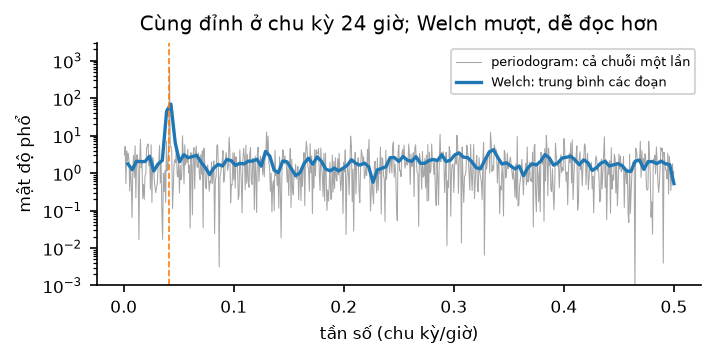

**Lý do.** Mọi chuỗi viết được thành tổng nhiều sóng đều đặn; phổ cho biết mỗi sóng to cỡ nào. Bật tắt thiết bị là dao động rất nhanh
(tần số cao); nhịp sinh hoạt nằm ở 1/24 chu kỳ mỗi giờ. Trừ trung bình trước, nếu không tần số 0 át hết.

**Kết quả.** Ví dụ tay (tần số tính theo chu kỳ mỗi bước), rồi hai cảm biến thật:

In [ ]:
def pho(y, fs=FS, nperseg=2048):
    # mật độ phổ Welch: trả (tần số theo chu kỳ/giờ, công suất); trừ trung bình trước
    y = np.asarray(y, dtype=float)
    return signal.welch(y - np.nanmean(y), fs=fs, nperseg=min(nperseg, y.size))


for v in ([1, -1, 1, -1, 1, -1], [1, 1, 1, -1, -1, -1]):
    f, P = signal.periodogram(v)
    print(v, "→ năng lượng lớn nhất ở tần số", round(float(f[np.argmax(P)]), 3), "chu kỳ/bước")

fig, truc = plt.subplots(1, 2, figsize=(10, 3))
for ax, cot, ten in zip(truc, ["Appliances", "T2"], ["điện thiết bị", "nhiệt độ phòng khách"], strict=True):
    f, P = pho(df[cot])
    nhanh = P[f > 1].sum() / P[1:].sum()
    print(f"{ten}: chu kỳ mạnh nhất {1 / f[1:][np.argmax(P[1:])]:.2f} giờ | phần năng lượng ở chu kỳ dưới 1 giờ {nhanh:.3f}")
    ax.loglog(f[1:], P[1:], lw=0.8)
    for ck in (24, 12, 1):
        ax.axvline(1 / ck, color="tab:orange", ls="--", lw=0.8)
    ax.set(title=ten, xlabel="tần số (chu kỳ/giờ); vạch: 24 giờ, 12 giờ, 1 giờ")
truc[0].set_ylabel("mật độ phổ")
plt.show()

Chuỗi lên xuống mỗi bước dồn hết năng lượng ở tần số 0,5 (lặp mỗi 2 bước); chuỗi lặp mỗi 6 bước dồn ở 1/6. Trên dữ liệu thật, cả hai
cảm biến có đỉnh ở chu kỳ 24,38 giờ (nhịp ngày). Điện thiết bị còn 17,8% năng lượng ở phía phải vạch 1 giờ; nhiệt độ phòng là 0,0 — nó không
thể nhảy trong vài phút.

**Bài học.** Đọc phổ trước mọi quyết định lọc. Tần số cao không có năng lượng (như `T2`) thì lọc chỉ thêm trễ.

## 3. Hạ mẫu mà không lọc trước sinh ra một chu kỳ 2,5 giờ không có thật

**Vấn đề.** Hạ mẫu 10 phút → 1 giờ là việc hằng ngày. Làm sai, nó **tạo ra** một chu kỳ không tồn tại.

> **tần số Nyquist** · *Nyquist frequency*
>
> - **Là gì:** tần số cao nhất còn thấy đúng khi lấy mẫu với tần số $f_s$: bằng $f_s / 2$ — mỗi vòng dao động phải được chụp ít nhất hai lần.
> - **Ví dụ:** $f_s$ = 6 mẫu/giờ → Nyquist 3 chu kỳ/giờ, tức chu kỳ ngắn nhất thấy đúng là 20 phút.
> - **Để làm gì:** biết trước sau khi hạ mẫu còn thấy được nhịp nào, nhịp nào sẽ thành ảo ảnh.

> **aliasing**
>
> - **Là gì:** dao động nhanh hơn Nyquist bị lấy mẫu thưa nên giả dạng thành dao động chậm: $f_{\text{giả}} = |f - k f_s|$ với $k = \operatorname{round}(f / f_s)$.
> - **Ví dụ:** sóng lặp mỗi 4 bước ($f$ = 1/4), lấy mẫu mỗi 3 bước ($f_s$ = 1/3): $|1/4 - 1/3|$ = 1/12, hiện thành sóng lặp mỗi 12 bước. Như bánh xe quay ngược trong phim.
> - **Để làm gì:** nhận ra một chu kỳ lạ sau `resample` là ảo ảnh, trước khi đi tìm nguyên nhân cho nó.
>
> 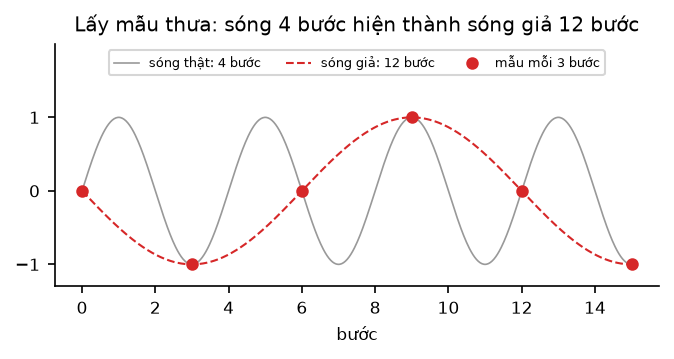

> **hạ mẫu (downsampling)** · *downsampling*
>
> - **Là gì:** giảm tần số lấy mẫu.
> - **Ví dụ:** 10 phút → 1 giờ: lấy mỗi 6 mẫu một, $f_s$ từ 6 xuống 1 mẫu/giờ, Nyquist từ 3 xuống 0,5 chu kỳ/giờ.
> - **Để làm gì:** dữ liệu gọn hơn, khớp tầm dự báo — nhưng dao động nhanh hơn Nyquist mới phải bỏ trước.

> **lọc thông thấp** · *low-pass filter*
>
> - **Là gì:** bộ lọc giữ dao động chậm (tần số thấp), bỏ dao động nhanh.
> - **Ví dụ:** cắt ở 0,4 chu kỳ/giờ: nhịp ngày (1/24 ≈ 0,04) đi qua gần nguyên, dao động 43 phút (1,4) bị chặn.
> - **Để làm gì:** chạy trước khi hạ mẫu để không còn gì nhanh hơn Nyquist mới mà giả dạng.
>
> 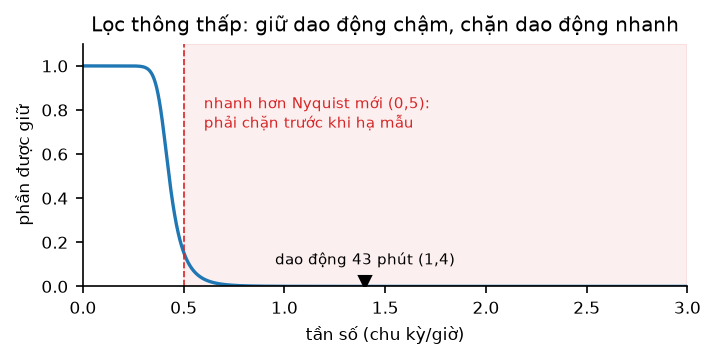

**Lý do.** Dao động nhanh không biến mất khi lấy mẫu thưa, nó "gập" xuống thành dao động chậm. Cách chữa: lọc thông thấp ở khoảng 0,8
lần Nyquist mới rồi mới lấy mẫu.

**Kết quả.** Ví dụ tay, rồi một chuỗi mô phỏng 10 phút một mẫu: nhịp ngày + dao động 43 phút (1,4 chu kỳ/giờ).

In [ ]:
song = np.round(np.sin(2 * np.pi * np.arange(16) / 4)) + 0
print("sóng 4 bước:", song[:8], "→ lấy mỗi 3 bước:", song[::3])


def f_gia(f, fs):
    return abs(f - round(f / fs) * fs)


print(f"chu kỳ giả của ví dụ tay: {1 / f_gia(1 / 4, 1 / 3):.0f} bước | 1,4 chu kỳ/giờ lấy mẫu mỗi giờ → {f_gia(1.4, 1.0):.1f} chu kỳ/giờ")


def ha_mau(y, buoc=6, loc_truoc=True):
    # lọc thông thấp Butterworth bậc 8 ở 0,8 × Nyquist mới rồi mới lấy mẫu; lọc hai chiều → chỉ để tiền xử lý lịch sử
    y = np.asarray(y, dtype=float)
    if not loc_truoc:
        return y[::buoc]
    sos = signal.butter(8, 0.8 * FS / buoc / 2, btype="low", fs=FS, output="sos")
    return signal.sosfiltfilt(sos, y)[::buoc]


def cong_suat_quanh(f, P, chu_ky_gio, rong=0.05):
    return float(P[np.abs(f - 1 / chu_ky_gio) < rong].sum())


t = np.arange(6000) / FS                                    # giờ
y_mp = 20 + 2 * np.sin(2 * np.pi * t / 24) + 0.5 * np.sin(2 * np.pi * 1.4 * t)
fig, ax = plt.subplots(figsize=(7, 2.8))
for loc, ten in ((False, "hạ mẫu thô"), (True, "lọc rồi hạ mẫu")):
    f, P = pho(ha_mau(y_mp, 6, loc), fs=1.0, nperseg=512)
    print(f"{ten}: công suất quanh chu kỳ 2,5 giờ = {cong_suat_quanh(f, P, 2.5):.1f}")
    ax.semilogy(f, P, label=ten)
ax.axvline(0.4, color="k", ls="--", lw=0.8)
ax.set(xlabel="tần số sau khi hạ mẫu (chu kỳ/giờ)", ylabel="mật độ phổ", title="Đỉnh ở 0,4 chỉ có khi hạ mẫu thô")
ax.legend(fontsize=8)
plt.show()

y15 = 0.5 * np.sin(2 * np.pi * 1.5 * t)                     # dao động 1,5 chu kỳ/giờ
print(f"dao động 1,5 chu kỳ/giờ lấy mẫu mỗi giờ: |mẫu| lớn nhất = {np.abs(y15[::6]).max():.1e}")

Ví dụ tay: mẫu 0, −1, 0, 1, 0, −1 lặp mỗi 4 mẫu, tức 12 bước gốc. Mô phỏng: 1,4 chu kỳ/giờ lớn hơn Nyquist mới 0,5, gập thành
$|1{,}4 - 1|$ = 0,4 chu kỳ/giờ — chu kỳ giả 2,5 giờ, công suất 64,0 khi hạ mẫu thô và 0,0 khi lọc trước. Dòng cuối là một cái bẫy khi tự
dựng ví dụ: dao động 1,5 chu kỳ/giờ gập đúng vào Nyquist, mọi mẫu bằng 0 nên phổ không thấy gì.

**Bài học.** Lọc thông thấp trước khi hạ mẫu. `resample("h").mean()` đã là một bộ lọc trung bình, tốt hơn `.first()`, nhưng cắt không
sắc. Bộ lọc chống aliasing ở đây chạy hai chiều: chỉ để làm sạch lịch sử, không dùng trong feature.

## 4. RMSE thấp nhất thuộc về các bộ lọc nhìn tương lai; trong nhóm nhân quả, Kalman filter tốt nhất

**Vấn đề.** Có nhiều họ bộ lọc; mỗi họ đổi độ trơn lấy trễ, hoặc lấy việc nhìn tương lai. So chúng thế nào cho công bằng?

> **EWMA** · *exponentially weighted moving average*
>
> - **Là gì:** trung bình trượt hàm mũ: $z_t = \alpha y_t + (1-\alpha) z_{t-1}$ — trọng số giảm dần theo cấp số nhân về quá khứ.
> - **Ví dụ:** $\alpha$ = 0,5, chuỗi 10, 20, 10: $z$ = 10; 0,5 × 20 + 0,5 × 10 = 15; 0,5 × 10 + 0,5 × 15 = 12,5.
> - **Để làm gì:** làm trơn nhân quả, trễ ít, chỉ cần nhớ một số — hợp dữ liệu đang chảy về.
>
> 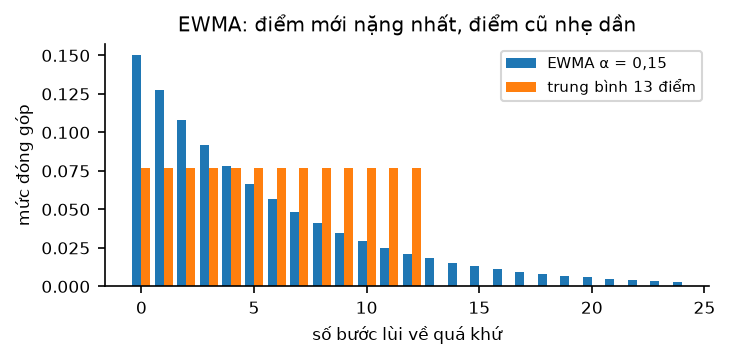

> **Savitzky–Golay** · *Savitzky–Golay filter*
>
> - **Là gì:** khớp một đa thức bậc thấp trên cửa sổ quanh mỗi điểm, lấy giá trị đa thức tại điểm đó.
> - **Ví dụ:** cửa sổ 13 điểm, bậc 2: mỗi điểm được thay bằng giá trị của parabol khớp nhất với 13 điểm quanh nó.
> - **Để làm gì:** làm trơn mà giữ chiều cao đỉnh (cảm biến, phổ học) — nhưng cửa sổ quanh điểm dùng tương lai, kể cả ở cuối chuỗi.
>
> 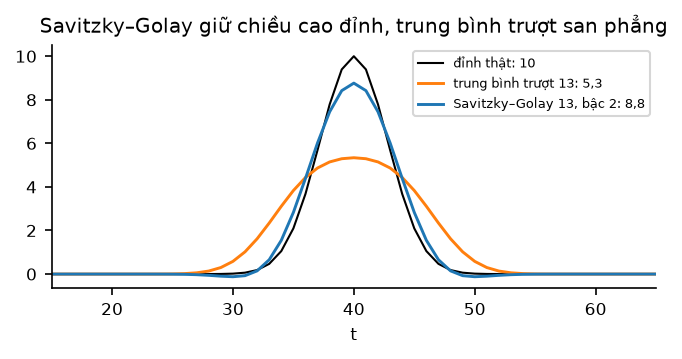

> **Butterworth** · *Butterworth filter*
>
> - **Là gì:** bộ lọc cắt tần số theo một ngưỡng; mỗi đầu ra tính từ cả đầu vào lẫn các đầu ra trước.
> - **Ví dụ:** cắt ở 0,4 chu kỳ/giờ, bậc 8: dao động chậm hơn đi qua gần nguyên, nhanh hơn 0,5 gần như mất hết.
> - **Để làm gì:** bỏ đúng một dải tần số (chống aliasing); đổi lại bản nhân quả trễ nhiều.

> **`sosfilt` / `sosfiltfilt`** · *second-order sections filter / forward-backward filter*
>
> - **Là gì:** `sosfilt` chạy bộ lọc một chiều theo thời gian; `sosfiltfilt` chạy xuôi rồi chạy ngược lại (bản ổn định số của `lfilter` / `filtfilt`).
> - **Ví dụ:** cùng một bộ lọc Butterworth: `sosfilt` trễ 19 bước, `sosfiltfilt` trễ 0 bước — vì lượt chạy ngược đã dùng tương lai.
> - **Để làm gì:** `sosfilt` dùng được làm feature; `sosfiltfilt` chỉ để mô tả, tiền xử lý lịch sử.
>
> 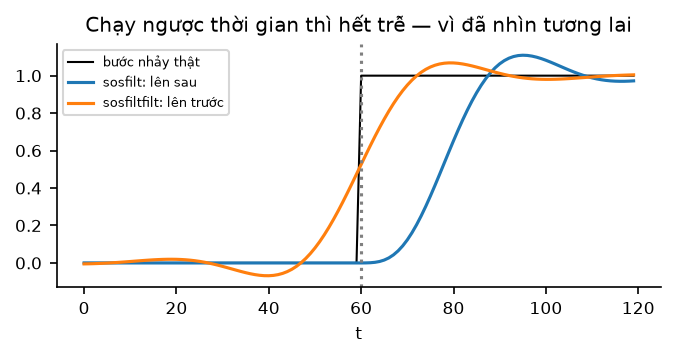

> **Kalman filter / smoother**
>
> - **Là gì:** ước lượng tín hiệu ẩn từ một mô hình (ở đây: mức đổi dần + nhiễu đo). Filter chỉ dùng quá khứ; smoother dùng cả chuỗi.
> - **Ví dụ:** mức ước lượng 10, số đo mới 14, mô hình tin số đo và mức cũ ngang nhau: filter cập nhật thành 12 (số minh hoạ).
> - **Để làm gì:** filter là bộ lọc nhân quả tốt khi có mô hình hợp, chịu được dữ liệu có lỗ; smoother chỉ để mô tả.

> **wavelet** · *wavelet denoising*
>
> - **Là gì:** tách chuỗi thành nhiều thang (nhanh, chậm), co các hệ số nhỏ của thang nhanh về 0, rồi ghép lại.
> - **Ví dụ:** 10, 12, 30, 30 → trung bình từng cặp 11, 30 (thang chậm) và nửa hiệu từng cặp −1, 0 (thang nhanh); đặt −1 về 0 rồi ghép: 11, 11, 30, 30 — nhiễu nhỏ mất, bước nhảy 11 → 30 còn nguyên.
> - **Để làm gì:** khử nhiễu mà giữ bước nhảy (dịch mức); nhưng ghép lại dùng cả chuỗi nên không nhân quả.

> **RMSE** · *root mean squared error*
>
> - **Là gì:** căn của trung bình bình phương sai số: $\sqrt{\tfrac{1}{n}\sum e_t^2}$.
> - **Ví dụ:** sai số 1 và −3: trung bình bình phương (1 + 9) / 2 = 5, căn 5 ≈ 2,24.
> - **Để làm gì:** đo bộ lọc cách tín hiệu thật bao xa (khi biết tín hiệu thật); phạt nặng sai số lớn.

**Lý do.** Dùng chuỗi mô phỏng mà ta **biết** tín hiệu thật: nhịp 144 bước + nhịp 36 bước + nhiễu độ lệch chuẩn 1 (seed 0). Khi đó đo
được RMSE so với tín hiệu thật, và đo trễ: dịch đầu ra lùi $k$ bước, chọn $k$ cho tương quan với tín hiệu thật lớn nhất (như tương quan
chéo). Tham số Kalman ước lượng trên phần đầu rồi cố định.

**Kết quả.** Mười cấu hình của sáu họ:

In [ ]:
print("EWMA tay:", pd.Series([10.0, 20, 10]).ewm(alpha=0.5, adjust=False).mean().tolist(),
      "| pandas mặc định adjust=True:", pd.Series([10.0, 20, 10]).ewm(alpha=0.5).mean().round(2).tolist())


def ma_truoc(y, cua_so=13):
    return pd.Series(np.asarray(y, dtype=float)).rolling(cua_so, min_periods=1).mean().to_numpy()


def ma_giua(y, cua_so=13):
    return pd.Series(np.asarray(y, dtype=float)).rolling(cua_so, center=True, min_periods=1).mean().to_numpy()


def ewma(y, alpha=0.15):
    return pd.Series(np.asarray(y, dtype=float)).ewm(alpha=alpha).mean().to_numpy()


def savitzky_golay(y, cua_so=13, bac=2):
    return signal.savgol_filter(np.asarray(y, dtype=float), cua_so, bac)


def butter_nhan_qua(y, cat=0.05):
    return signal.sosfilt(signal.butter(4, cat, output="sos"), np.asarray(y, dtype=float))


def butter_filtfilt(y, cat=0.05):
    return signal.sosfiltfilt(signal.butter(4, cat, output="sos"), np.asarray(y, dtype=float))


def kalman(y, lam_tron=False, tham_so=None):
    # local level; tham_so=None → ước lượng trên CHÍNH chuỗi đưa vào (làm cả filter mất nhân quả)
    mo_hinh = UnobservedComponents(np.asarray(y, dtype=float), level="local level")
    p = mo_hinh.fit(disp=0).params if tham_so is None else tham_so
    return mo_hinh.smooth(p).smoothed_state[0] if lam_tron else mo_hinh.filter(p).filtered_state[0]


def tham_so_kalman(y_hoc):
    return UnobservedComponents(np.asarray(y_hoc, dtype=float), level="local level").fit(disp=0).params


def wavelet(y, song="db4", muc=4):
    # ngưỡng mềm σ√(2 ln n), σ = MAD của thang mịn nhất / 0,6745
    y = np.asarray(y, dtype=float)
    he_so = pywt.wavedec(y, song, level=muc)
    nguong = np.median(np.abs(he_so[-1])) / 0.6745 * np.sqrt(2 * np.log(y.size))
    return pywt.waverec([he_so[0]] + [pywt.threshold(c, nguong, mode="soft") for c in he_so[1:]], song)[: y.size]


def bo_loc_mac_dinh(y_hoc):
    p = tham_so_kalman(y_hoc)
    return {"MA trailing 13": ma_truoc, "MA centered 13": ma_giua, "EWMA α=0,15": ewma,
            "Savitzky–Golay 13": savitzky_golay, "Butterworth nhân quả": butter_nhan_qua,
            "Butterworth filtfilt": butter_filtfilt,
            "Kalman filter (tham số cố định)": lambda v: kalman(v, False, p),
            "Kalman filter (khớp lại cả chuỗi)": lambda v: kalman(v, False),
            "Kalman smoother": lambda v: kalman(v, True, p), "Wavelet db4": wavelet}

In [ ]:
def sinh_tin_hieu(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    that = 10 + 3 * np.sin(2 * np.pi * t / 144) + 1.5 * np.sin(2 * np.pi * t / 36)
    return that, that + rng.normal(0, 1.0, n)


def rmse(z, that):
    return float(np.sqrt(np.nanmean((np.asarray(z, dtype=float) - that) ** 2)))


def tre_pha(z, that, toi_da=40):
    z = np.nan_to_num(np.asarray(z, dtype=float) - np.nanmean(z))
    that = np.asarray(that, dtype=float) - np.mean(that)
    return int(np.argmax([np.corrcoef(z[k:], that[: that.size - k])[0, 1] for k in range(toi_da)]))


print("RMSE ví dụ tay (sai số 1, −3):", round(rmse([1, -3], np.zeros(2)), 2))
that, mp = sinh_tin_hieu()
BO_LOC = bo_loc_mac_dinh(mp[: mp.size // 3])            # tham số Kalman: chỉ 1/3 đầu
ra = {ten: np.asarray(ham(mp), dtype=float) for ten, ham in BO_LOC.items()}
bang = pd.DataFrame({"RMSE": {ten: rmse(z, that) for ten, z in ra.items()},
                     "trễ (bước)": {ten: tre_pha(z, that) for ten, z in ra.items()}})
print(bang.round(3))

doan = slice(600, 900)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(2000)[doan], mp[doan], color="0.75", lw=0.6, label="có nhiễu")
ax.plot(np.arange(2000)[doan], that[doan], color="k", lw=1.5, label="tín hiệu thật")
for ten in ("MA trailing 13", "MA centered 13", "Kalman filter (tham số cố định)"):
    ax.plot(np.arange(2000)[doan], ra[ten][doan], lw=1.1, label=ten)
ax.set(title="Trailing chạy sau tín hiệu thật; centered trùng khít vì đã nhìn tương lai", xlabel="t (bước)")
ax.legend(fontsize=7, ncols=3)
plt.show()

Ba RMSE thấp nhất — centered (0,357), Kalman smoother, Savitzky–Golay — đều dùng tương lai. Trong nhóm nhân quả, Kalman filter tốt
nhất (0,584, trễ 1); Butterworth nhân quả tệ nhất (2,419) vì trễ 19 bước. Trailing 13 trễ đúng (13 − 1)/2 = 6; EWMA $\alpha$ = 0,15 trễ 4
mà RMSE thấp hơn. Hai dòng Kalman filter gần như bằng nhau — khác nhau ở chỗ phần sau mới thấy.

**Bài học.** Độ trơn phải trả bằng trễ, hoặc bằng việc nhìn tương lai. Xếp hạng bộ lọc cho dự báo thì chỉ so các bộ lọc nhân quả với
nhau. Với EWMA luôn ghi rõ tham số: $\alpha = 2/(\text{span}+1) = 1/(1+\text{com})$, và `adjust=True` (mặc định) khác công thức tay ở vài
điểm đầu (16,67 thay cho 15).

## 5. Đổi đuôi chuỗi, xem phần trước: 6 trên 10 cấu hình nhìn tương lai

**Vấn đề.** Tài liệu thư viện không phải lúc nào cũng nói rõ; và bộ lọc nhân quả vẫn rò rỉ nếu **tham số** của nó ước lượng trên cả
chuỗi. Cần một phép thử chạy được trên mọi hàm.

**Lý do.** Như ví dụ 5 giờ ở phần 1: cộng 50 vào 10 giá trị **cuối**, chạy lại, so đầu ra ở **mọi** mốc trước đó; nhân quả thì phần
trước không nhúc nhích. Dung sai theo thang dữ liệu ($10^{-7}$ × giá trị lớn nhất) vì số thực có sai số tính toán rất nhỏ.

**Kết quả.**

In [ ]:
def kiem_nhan_qua(ham_loc, y, so_diem_doi=10, thay_doi=50.0):
    y = np.asarray(y, dtype=float)
    k0 = y.size - so_diem_doi
    goc = np.asarray(ham_loc(y), dtype=float)
    y_doi = y.copy()
    y_doi[k0:] += thay_doi
    moi = np.asarray(ham_loc(y_doi), dtype=float)
    lech = np.abs(np.nan_to_num(moi[:k0]) - np.nan_to_num(goc[:k0]))     # MỌI mốc trước điểm đổi
    nguong = max(1e-9, 1e-7 * float(np.nanmax(np.abs(y))))
    return {"đổi quá khứ tối đa": float(lech.max()), "nhìn tương lai?": bool(lech.max() > nguong),
            "mốc đầu tiên bị đổi": int(np.argmax(lech > nguong)) if lech.max() > nguong else -1}


kiem = pd.DataFrame({ten: kiem_nhan_qua(ham, mp) for ten, ham in BO_LOC.items()}).T
print(kiem.to_string(float_format="{:.3f}".format))
print("số cấu hình nhìn tương lai:", int(kiem["nhìn tương lai?"].sum()), "/", len(kiem))
print("filtfilt trên chuỗi 400 điểm, mốc đầu tiên bị đổi:", kiem_nhan_qua(butter_filtfilt, sinh_tin_hieu(400)[1])["mốc đầu tiên bị đổi"])

Trailing, EWMA, Butterworth `sosfilt` và Kalman filter tham số cố định đổi 0,000; sáu cấu hình còn lại đổi quá khứ. Centered 13 đổi
23,077 = 6 × 50 / 13: sáu điểm cuối của nửa cửa sổ tương lai. Đáng nhớ nhất là hai dòng Kalman filter: cùng một bộ lọc, chỉ khác chỗ lấy
tham số, mà bản khớp lại trên cả chuỗi đổi 1,134 — rò rỉ qua tham số. `filtfilt` trên 400 điểm bị đổi từ mốc 126: làm bẩn ngược 274 bước.

**Bài học.** Chạy bài kiểm này cho **mọi** hàm sinh feature, kể cả hàm "chắc chắn nhân quả", và so cả đoạn sát điểm đổi — đó đúng là
chỗ lộ vi phạm. Tham số chỉ ước lượng trên phần học rồi cố định. Bài kiểm chỉ bắt rò rỉ qua đuôi chuỗi; rò rỉ qua cách chia tập cần kiểm
khác.

## 6. Feature nhìn tương lai giảm MAE 24–28% giả; feature nhân quả chỉ 1–6%

**Vấn đề.** Feature nhìn tương lai làm sai số đẹp bao nhiêu? Và nếu làm trơn chính **mục tiêu** thì sao?

**Lý do.** Dự báo điện thiết bị một giờ tới (6 bước) bằng hồi quy tuyến tính trên hai biến: đầu ra bộ lọc và giá trị hiện tại. Học trên
70% đầu, chấm MAE trên 30% sau, **trên chuỗi gốc**. Tham số Kalman chỉ ước lượng trên phần học.

**Kết quả.**

In [ ]:
def danh_gia_feature(y, ham_loc, tam=TAM, ty_le_hoc=0.7):
    # MAE khi dự báo y_{t+tam} bằng hồi quy trên [bộ lọc(y)_t, y_t]; chấm trên CHUỖI GỐC
    bang = pd.DataFrame({"loc": np.asarray(ham_loc(y.to_numpy()), dtype=float), "y": y.to_numpy(),
                         "muc_tieu": y.shift(-tam).to_numpy()}).dropna()
    cat = int(len(bang) * ty_le_hoc)
    hoc, kt = bang.iloc[:cat], bang.iloc[cat:]
    he_so = np.linalg.lstsq(np.column_stack([np.ones(len(hoc)), hoc["loc"], hoc["y"]]), hoc["muc_tieu"], rcond=None)[0]
    du_bao = np.column_stack([np.ones(len(kt)), kt["loc"], kt["y"]]) @ he_so
    return float(np.mean(np.abs(du_bao - kt["muc_tieu"].to_numpy())))


dien = df["Appliances"]
BO_LOC_THAT = bo_loc_mac_dinh(dien.to_numpy()[: int(len(dien) * 0.7)])
goc = danh_gia_feature(dien, lambda v: v)
gia = pd.DataFrame({ten: {"MAE": danh_gia_feature(dien, ham),
                          "nhìn tương lai?": kiem_nhan_qua(ham, dien.to_numpy())["nhìn tương lai?"]}
                    for ten, ham in BO_LOC_THAT.items()}).T
gia["MAE"] = gia["MAE"].astype(float)
gia["so với không lọc (%)"] = (gia["MAE"] / goc - 1) * 100
print(f"không lọc: MAE {goc:.2f} Wh")
print(gia.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(gia)), gia["MAE"], color=["tab:orange" if v else "tab:blue" for v in gia["nhìn tương lai?"]])
ax.axhline(goc, color="0.4", ls="--", label="không lọc")
ax.set_xticks(range(len(gia)), gia.index, rotation=25, ha="right", fontsize=7)
ax.set(ylabel="MAE 1 giờ tới (Wh)", title="Cam = nhìn tương lai: MAE thấp nhưng không dùng được khi dự báo thật")
ax.legend(fontsize=8)
plt.show()

Không lọc: 46,84 Wh. Centered (−27,7%) và `filtfilt` (−24,5%) trông như feature tuyệt vời — phần thưởng mất sạch khi dùng thật, vì
lúc đó không có số của giờ sau. Feature nhân quả chỉ giúp 0,9–5,9%; Butterworth nhân quả trễ 19 bước cho dự báo 6 bước tới nên chỉ giúp
1,0%. Nguy hiểm hơn là Savitzky–Golay (−5,9%) và wavelet (−7,1%): rò rỉ mà chỉ giảm một chút, trông hợp lý — chỉ bài kiểm tự động bắt được.

Giờ làm trơn **mục tiêu**: cùng một mô hình (hồi quy trên giá trị hiện tại), chấm trên điện thật và trên điện đã làm trơn bằng centered 13.

In [ ]:
def cham_hai_muc_tieu(y, ham_loc=ma_giua, tam=TAM):
    bang = pd.DataFrame({"y": y, "tron": ham_loc(y.to_numpy())}, index=y.index).assign(
        mt_goc=lambda d: d["y"].shift(-tam), mt_tron=lambda d: d["tron"].shift(-tam)).dropna()
    cat = int(len(bang) * 0.7)
    hoc, kt = bang.iloc[:cat], bang.iloc[cat:]
    he_so = np.linalg.lstsq(np.column_stack([np.ones(len(hoc)), hoc["y"]]), hoc["mt_goc"], rcond=None)[0]
    du_bao = np.column_stack([np.ones(len(kt)), kt["y"]]) @ he_so
    return {"MAE trên điện thật": float(np.mean(np.abs(du_bao - kt["mt_goc"]))),
            "MAE trên điện đã làm trơn": float(np.mean(np.abs(du_bao - kt["mt_tron"])))}


kq = cham_hai_muc_tieu(dien)
print({k: round(v, 2) for k, v in kq.items()}, f"| giảm {1 - kq['MAE trên điện đã làm trơn'] / kq['MAE trên điện thật']:.1%}")

doan = dien["2016-05-01":"2016-05-03"]
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(doan, color="0.6", lw=0.9, label="mục tiêu thật")
ax.plot(doan.index, ma_giua(doan.to_numpy()), color="tab:orange", lw=1.6, label="mục tiêu đã làm trơn")
ax.set(ylabel="Wh", title="Làm trơn mục tiêu cắt mất các đỉnh — đúng chỗ mô hình sai nhiều nhất")
ax.legend(fontsize=8)
plt.show()

MAE 35,78 trên mục tiêu đã làm trơn so với 46,84 trên điện thật: giảm 23,6% mà mô hình không đổi. Nó chỉ được chấm trên một đại lượng
dễ hơn và không có thật — không ai trả tiền điện "đã làm trơn". Muốn dự báo "điện trung bình 3 giờ tới" thì định nghĩa mục tiêu là trung
bình các giờ **tương lai** và ghi rõ.

**Bài học.** Năm câu hỏi chọn bộ lọc: đầu ra dùng làm gì (feature, mục tiêu → chỉ nhân quả)? Phổ có năng lượng ở tần số cao không? Trễ
bao nhiêu so với tầm dự báo? Có bước nhảy không (có thì tìm điểm gãy trước, lọc từng đoạn)? Tham số lấy từ đâu (chỉ phần học)?

## 7. Bài tập về nhà — đáp số

**Bài 1 — Quét $\alpha$.** MAE dự báo 1 giờ tới khi feature là EWMA với $\alpha$ từ 0,05 tới 0,9:

In [ ]:
alpha = np.round(np.arange(0.05, 0.95, 0.05), 2)
mae_a = pd.Series([danh_gia_feature(dien, lambda v, a=a: ewma(v, a)) for a in alpha], index=alpha)
print(mae_a.round(2).to_string())
print(f"tốt nhất: α = {mae_a.idxmin()}, MAE {mae_a.min():.2f} (không lọc {goc:.2f})")
ax = mae_a.plot(marker="o", figsize=(6, 2.6), title="MAE theo α: nhỏ quá thì trễ, lớn quá thì còn nhiễu")
ax.set(xlabel="α", ylabel="MAE (Wh)")
plt.show()

MAE thấp nhất ở $\alpha$ = 0,15–0,2 (44,10 Wh). $\alpha$ nhỏ (0,05) trơn nhưng trễ nhiều nên feature đến muộn; $\alpha$ lớn (0,9) gần như
không lọc, còn nguyên nhiễu, MAE về sát mức không lọc. Điểm tốt nhất ở giữa là chỗ cân bằng nhiễu – trễ, và vẫn chỉ tốt hơn không lọc
gần 6%.

**Bài 2 — Bộ lọc HP trên `T2`.** Hodrick–Prescott tách xu hướng bằng cách giải một bài toán trên **cả** chuỗi. Áp bài kiểm nhân quả, rồi
cắt 100 điểm cuối và so xu hướng ở 100 điểm ngay trước chỗ cắt:

In [ ]:
from statsmodels.tsa.filters.hp_filter import hpfilter


def xu_huong_hp(v):
    return hpfilter(np.asarray(v, dtype=float), lamb=1600)[1]


t2 = df["T2"].to_numpy()
print("bài kiểm nhân quả:", kiem_nhan_qua(xu_huong_hp, t2))
day_du, cut = xu_huong_hp(t2), xu_huong_hp(t2[:-100])
lech_cuoi = np.abs(day_du[-200:-100] - cut[-100:])          # 100 điểm cuối của bản cắt = cuối mẫu
lech_giua = np.abs(day_du[5000:5100] - cut[5000:5100])      # cùng hai bản, ở giữa chuỗi
print(f"xu hướng đổi khi thêm 100 điểm: ở cuối mẫu tối đa {lech_cuoi.max():.3f} °C | ở giữa chuỗi tối đa {lech_giua.max():.1e} °C")

Bài kiểm báo HP nhìn tương lai: quá khứ đổi tới 22,8 khi cộng 50 vào 10 điểm cuối. Thêm 100 điểm mới, xu hướng ở cuối mẫu cũ bị viết
lại tới 0,069 °C, còn ở giữa chuỗi gần như không đổi ($10^{-12}$). Đúng điều Hamilton (2018) mô tả: giá trị HP ở **cuối** mẫu — chỗ dự
báo bắt đầu — khác hẳn giá trị ở giữa. HP chỉ để mô tả lịch sử.

**Bài 3 — Wavelet với bước nhảy.** Thêm dịch mức +100 vào chuỗi mô phỏng từ mốc 1.000; so RMSE quanh mốc nhảy (±20 điểm) và ở phần
còn lại:

In [ ]:
that_n, mp_n = that.copy(), mp.copy()
that_n[1000:] += 100
mp_n[1000:] += 100
quanh = np.zeros(2000, dtype=bool)
quanh[980:1020] = True
for ten, ham in (("Wavelet db4", wavelet), ("MA trailing 13", ma_truoc)):
    sai = np.asarray(ham(mp_n), dtype=float) - that_n
    print(f"{ten:<15} RMSE quanh mốc nhảy {np.sqrt(np.mean(sai[quanh] ** 2)):6.2f} | phần còn lại {np.sqrt(np.mean(sai[~quanh] ** 2)):.2f}")

Quanh mốc nhảy, wavelet sai 2,08, trailing 13 sai 31,44: trailing bôi bước nhảy +100 ra 13 điểm và trễ theo, wavelet giữ được cạnh.
Ở phần còn lại wavelet cũng tốt hơn (0,65 so với 1,13) — nhưng nó không nhân quả, chỉ dùng để làm sạch lịch sử.

## Tự kiểm

- [ ] Tính trung bình trượt 3 điểm trailing và centered tại điểm thứ ba của 4, 8, 6, 10; chỉ ra kiểu nào dùng số 10.
- [ ] Đỉnh phổ ở 1/168 chu kỳ mỗi giờ là nhịp gì?
- [ ] Dao động chu kỳ 20 phút, hạ mẫu thành 15 phút một mẫu không lọc: nó giả dạng thành chu kỳ bao nhiêu phút?
- [ ] EWMA $\alpha$ = 0,2, $z_{t-1}$ = 50, $y_t$ = 100: tính $z_t$; `span=9` ứng với $\alpha$ bao nhiêu?
- [ ] Giải thích vì sao hai Kalman filter có RMSE gần như nhau mà chỉ một cái nhân quả.
- [ ] Nói vì sao MAE trên mục tiêu đã làm trơn không được đưa vào báo cáo.